In [1]:
### Script for Pathway enrichment analysis on MOFA results; requires a prepared pathway set input dataset

#############################################
# Prerequisites - Load Libraries

In [2]:
source('MS1_Functions.r')

In [3]:
### Inform about execution start
popup_function_pos('06_Downstream_Pathways: Execution Started')

In [4]:
source('MS0_Libraries.r')

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/miniconda3/envs/my_jupyter_env/lib/R/library/"


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘tibble’ was built under R version 4.3.3”
Warning message:
“package ‘purrr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.3”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
Warning message:
“package ‘lubridate’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘backports’ w

In [5]:
source('MS2_Plot_Config.r')

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


###############################################
# Preqrequisites Configurations & Parameters

In [6]:
### Load the parameters that are set via the configuration files

In [7]:
### Load configurations file
global_configs = read.csv('configurations/Data_Configs.csv', sep = ',')

In [8]:
head(global_configs,2)

,parameter,value
,<chr>,<chr>
1,data_path,/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/input_data/
2,result_path,/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/results/


In [9]:
data_path = global_configs$value[global_configs$parameter == 'data_path']

In [10]:
data_path

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/input_data/"

In [11]:
result_path = global_configs$value[global_configs$parameter == 'result_path']

In [12]:
result_path

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/results/"

In [13]:
### Load the configuration for the pathway enrichment from the config file

In [14]:
pathway_configs = read.csv('configurations/06_Pathway_Configs.csv', sep = ',')
pathway_configs = pathway_configs[pathway_configs$mofa_result_name != '',]

In [15]:
head(pathway_configs)

,mofa_result_name,factor_set,coverage_par,types,coverage_plot,p_value_plot,max_pathways_plot,enrichment_plot,top_features_plot,pathway_selection
,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<lgl>
1,CGS_v3_MOFA,3,0.05,"Activated.T.cells,B.Cells,Classical.Monocytes,Dendritic.cells,NK.cells,Regulatory.T.cells,T.cells",0.05,0.09,10,positive,0.05,NA


In [16]:
### Generate the result data directory if it does not exist yet
if(!file.exists(paste0(result_path, '06_results'))){
    dir.create(file.path(paste0(result_path, '06_results')))
    }

# Define parameters 

In [17]:
### Save values from loaded config file in variables

In [18]:
## For the calculation of the pathway enrichment

In [19]:
mofa_name = pathway_configs$mofa_result_name[1]   # mofa results that should be used

In [20]:
factor_set = as.numeric(unlist(str_split(pathway_configs$factor_set[1], ',')))  # factors for which enrichment analysis should be executed

In [21]:
factor_set

[1] 3

In [22]:
length(factor_set)

[1] 1

In [23]:
### Factor set needs to be at least first to factors if factor-set only one factor does not work

In [24]:
if(length(factor_set) <= 1){
    if(factor_set <= 1){
        factor_set = c(1,2)}
    }
if(length(factor_set) <= 1){
    if(factor_set > 1){
        factor_set = 1:factor_set
        }
    }

In [25]:
factor_set

[1] 1 2 3

In [26]:
coverage_par = pathway_configs$coverage_par[1] # coverage parameter: how many of the genes of a pathway need to be included in the MOFA feature set for testing this pathway for enrichment

In [27]:
coverage_par

[1] 0.05

In [28]:
views_set = unlist(str_split( pathway_configs$types[1], ','))  # extract the views for which a view-specific pathway enrichment analysis should be executed

In [29]:
views_set

[1] "Activated.T.cells"   "B.Cells"             "Classical.Monocytes"
[4] "Dendritic.cells"     "NK.cells"            "Regulatory.T.cells" 
[7] "T.cells"

In [30]:
## Parameters for the visualization of pathways

In [31]:
### Select pathways based on thresholds (like coverage, p-value, direction of enrichment)
coverage_plot = pathway_configs$coverage_plot[1]
p_value_cutoff_plot =pathway_configs$p_value_plot[1]
max_pathways =pathway_configs$max_pathways_plot[1]
select_enrichment = pathway_configs$enrichment_plot[1]

### Alternative: select pathways based on their specified names
pathway_selection_var =pathway_configs$pathway_selection[1]

In [32]:
pathway_selection_var

[1] NA

In [33]:
### For visualization define which genes should be ploted (need to be among the top x% of features for the Factor)
top_var_thres =pathway_configs$top_features_plot[1] # choose threshold of top x % of features of MOFA factor to take into account

In [34]:
## Fixed parameters (may be modified here)

In [35]:
## For enrichment calculation
use_statistic = "rank.sum" # which statistic to use to calcuate the enrichment; alternatives: mean.diff, rank.sum
use_test = 'parametric'  # which test to use to test the enrichment; alternatives: permutation, parametric, "cor.adj.parametric"
p_val_cutoff = 0.05
min_size = 5

# Load Data 

## Model Data

In [36]:
### Load the trained MOFA Model

In [37]:
model_name =  paste0("03_MOFA_MODEL_", mofa_name,'.hdf5')

In [38]:
outfile = file.path( paste0(result_path, '/03_results/',  model_name) )

In [39]:
outfile

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/results//03_results/03_MOFA_MODEL_CGS_v3_MOFA.hdf5"

In [40]:
if(file.exists(outfile)){
    model <- load_model(outfile, verbose = TRUE)
    popup_function_pos(paste0('Loaded: ', model_name))
    } else {popup_function_neg(paste0('Error: ',result_path, '/03_results/ ', model_name, 'could not be loaded. Check whether the previous steps have been executed successfully')) } 

Loading data...

Loading expectations for 2 nodes...

Loading model options...

Loading training options and statistics...

Assigning names to the different dimensions...

Re-ordering factors by their variance explained...

Doing quality control...

Checking views names...

Checking groups names...

Checking samples names...

Checking features names...

Checking dimensions...

Checking there are no features with complete missing values...

Checking sample covariates...

Checking expectations...

Checking for intercept factors...

Checking for highly correlated factors...



## Pathways

In [41]:
### Load the pre-defined pathway set( needs to include the columns:
# ID (unique identifier of the pathway)
# gene : gene-symbol of the gene belonging to the pathway (will be matched to the MOFA features)
# pathway_name: a textual description of the pathway 

In [42]:
path = paste0(data_path, 'Prepared_Pathway_Data.csv')
if(file.exists(path)){
    pathways =  read.csv(path)
    pathways$X = NULL 
    popup_function_pos(paste0('Loaded: ','Prepared_Pathway_Data.csv'))
    

} else{  popup_function_neg(paste0('Error: ','Prepared_Pathway_Data.csv', ' could not be loaded. Make sure the file is included within the specified input data folder'))
       print(paste0('Error: ','Prepared_Pathway_Data.csv', ' could not be loaded. Make sure the file is included within the specified input data folder'))
      
      
      }

In [43]:
head(pathways,2)

,ID,gene,pathway_name
,<chr>,<chr>,<chr>
1,R-HSA-1059683,JAK1,Interleukin-6 signaling
2,R-HSA-1059683,STAT1,Interleukin-6 signaling


# Prepare model data

## Extract the weights from the model

In [44]:
### Get the feature weights from the model and prepare the format

In [45]:
weights = get_weights(model, views = "all", factors = "all")
weight_data = data.frame()
for (i in names(weights)){
    data = data.frame(weights[[i]])
    data$type = i
    weight_data = rbind(weight_data,data)
}
weight_data$variable_name = rownames(weight_data)
weight_data$view <- weight_data$type 
weight_data$gene = sapply(strsplit(weight_data$variable_name, "_"), "[", 3)
head(weight_data)

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,Factor11,Factor12,Factor13,type,variable_name,view,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
Activated.T.cells__AAK1,0.41700115,-0.034792242,0.06532119,-0.17724194,0.06169439,-0.13583572,-0.21201313,-0.41205046,-0.08408664,-0.38306502,0.20192060,-0.42611677,-0.083121626,Activated.T.cells,Activated.T.cells__AAK1,Activated.T.cells,AAK1
Activated.T.cells__ABLIM1,-0.13813270,0.006765715,0.35685062,0.44976934,-0.07258608,0.09069702,-0.09551516,-0.02466334,-0.38630301,-0.04001327,0.01562036,-0.67204634,-0.021362726,Activated.T.cells,Activated.T.cells__ABLIM1,Activated.T.cells,ABLIM1
Activated.T.cells__AC007952.4,0.04292732,-0.308460347,-0.47819405,-0.11334720,0.01797809,-0.46267451,-0.24277116,-0.46103281,0.09396129,0.09664377,-0.25780624,0.35725075,0.079523753,Activated.T.cells,Activated.T.cells__AC007952.4,Activated.T.cells,AC007952.4
Activated.T.cells__AC016831.7,-0.33950558,0.285793549,-0.17591274,-0.16509115,0.01476009,-0.14039118,-0.08959743,-0.19904643,-0.03780450,0.02264113,-0.40698288,0.08090842,0.024495762,Activated.T.cells,Activated.T.cells__AC016831.7,Activated.T.cells,AC016831.7
Activated.T.cells__AC022217.3,0.35732108,-0.034005755,-0.46738407,-0.02080173,-0.02899924,-0.27598108,-0.24878547,-0.37083400,0.06824565,-0.41975431,-0.36048025,0.41068569,0.003418782,Activated.T.cells,Activated.T.cells__AC022217.3,Activated.T.cells,AC022217.3
Activated.T.cells__AC023424.3,0.12113409,0.185170910,-0.52896990,0.34913919,-0.09876328,0.08436995,-0.19158212,-0.09882538,0.04545903,-0.19411569,0.01208121,-0.20018975,-0.055855472,Activated.T.cells,Activated.T.cells__AC023424.3,Activated.T.cells,AC023424.3


In [46]:
## Transform to long format

In [47]:
feature_weights_long = melt(weight_data)

Using type, variable_name, view, gene as id variables



In [48]:
top_genes <- read.csv("top_500_genes_common_in_pseudobulk.csv")
# Assuming the gene column in your CSV is named "gene" - adjust if needed
top_genes_list <- top_genes$same_genes  

### Filter feature_weights_long to include only the top genes
###feature_weights_long <- feature_weights_long[feature_weights_long$gene %in% top_genes_list,]

In [49]:
top_genes_list

[1] "NLRP3"        "AP1S2"        "LINC01588"    "PNRC1"        "SERPINB9"    
  [6] "SEPTIN4.AS1"  "IL1B"         "NFKBIZ"       "FTH1"         "FLNA"        
 [11] "TMEM107"      "RNF19B"       "PFKFB3"       "IER3"         "PMAIP1"      
 [16] "PLAUR"        "LCP2"         "OLR1"         "NFKB1"        "GCH1"        
 [21] "AZIN1.AS1"    "NFKBIA"       "MAP3K8"       "GPR132"       "OGFRL1"      
 [26] "AQP9"         "STX11"        "CCL3"         "IRAK2"        "CCL4L2"      
 [31] "CDKN1A"       "IFNGR2"       "TGFB1"        "DENND5A"      "ECE1"        
 [36] "PILRA"        "S100A10"      "ICAM1"        "RNF125"       "ETS2"        
 [41] "TNFAIP8"      "ANXA1"        "ADAMTSL4.AS1" "UBE2D1"       "TNF"         
 [46] "ITGAV"        "BCL2A1"       "CCL3L1"       "ANXA5"        "TAGAP"       
 [51] "TNFAIP2"      "EIF4E"        "PTGER4"       "NFE2L2"       "P2RY8"       
 [56] "PELI1"        "HLA.DPA1"     "MIR3945HG"    "IL10RA"       "STK10"       
 [61] "MIR222HG"     "TNIP1"        "PLK3"         "BTG1"         "ZFP36L2"     
 [66] "TOM1"         "SLC9A8"       "EHD1"         "CCNI"         "CD37"        
 [71] "CHMP4B"       "LACTB"        "SH3BGRL3"     "PPT1"         "PPP2R5C"     
 [76] "KDM6B"        "GNAI2"        "SEC11A"       "CCL4"         "LPXN"        
 [81] "MAPK6"        "CXCL8"        "ITGAX"        "PTGS2"        "AHNAK"       
 [86] "BASP1"        "CD44"         "NOCT"         "NINJ1"        "ZNF331"      
 [91] "B3GNT5"       "GSTO1"        "ITGA5"        "ZNF267"       "MYH9"        
 [96] "PTP4A2"       "TNFRSF1B"     "PHLDA1"       "DUSP2"        "HLA.DPB1"    
[101] "KMO"          "VOPP1"        "USP36"        "NFAT5"        "TNFAIP3"     
[106] "FGR"          "CD58"         "USP3"         "BID"          "ARFGAP3"     
[111] "ELK3"         "MCL1"         "NDUFS5"       "CITED2"       "ARHGAP31"    
[116] "PPP1R15A"     "ZFP36"        "PIM3"         "SMS"          "CD302"       
[121] "CDC42EP3"     "MYOF"         "DEK"          "CD83"         "FLOT1"       
[126] "SPOCK2"       "SRSF5"        "PIK3R5"       "PDE4B"        "ALDH1A2"     
[131] "CAST"         "MSN"          "SNX9"         "CXCL2"        "AZIN1"       
[136] "METRNL"       "CXCR4"        "LMNA"         "TMSB4X"       "AREG"        
[141] "ARL4C"        "EVI2B"        "LUCAT1"       "ADA2"         "UBE2J1"      
[146] "BTG2"         "B2M"          "SNU13"        "KLF10"        "USP12"       
[151] "RIPK1"        "IL6R"         "HNRNPUL1"     "SAMSN1"       "CCNH"        
[156] "HERPUD2"      "HMGB2"        "JUND"         "NCOA4"        "TIPARP"      
[161] "CD96"         "BHLHE40"      "TEX14"        "TSC22D3"      "VIM"         
[166] "SUSD6"        "CSF3R"        "ITM2B"        "ABCA1"        "SLC7A5"      
[171] "B4GALT1"      "NACA"         "ARL8B"        "COTL1"        "FNIP2"       
[176] "LINC00910"    "TPI1"         "HLA.B"        "ADGRE2"       "HIGD2A"      
[181] "LSP1"         "LINC00513"    "TUBA4A"       "LGALS3"       "CCL5"        
[186] "SOD2"         "SKIL"         "FBXO33"       "DRAM1"        "ATP13A3"     
[191] "NCF2"         "MYO9B"        "MARCKS"       "MANBA"        "H1FX"        
[196] "EIF2AK3"      "HADHA"        "CARD16"       "RDX"          "RAPGEF1"     
[201] "ATP6AP2"      "KLF2"         "LRRFIP1"      "KLF6"         "CLIC4"       
[206] "ERP29"        "MBP"          "MIDN"         "ACSL1"        "UPP1"        
[211] "BCAS2"        "RASGEF1B"     "HNRNPK"       "EIF1"         "NIBAN1"      
[216] "CIB1"         "PCBP1"        "PPIF"         "OAZ1"         "C12orf57"    
[221] "SKP1"         "SLC12A2"      "SIK3"         "MAN1A1"       "FGD4"        
[226] "HSPH1"        "LRRC23"       "HSP90AA1"     "SCML4"        "USP32"       
[231] "CNOT2"        "HSPE1"        "INTS6"        "HSPA1B"       "RLF"         
[236] "MAPK14"       "ANKRD17"      "TAOK3"        "ARIH1"        "ERO1B"       
[241] "SF3B5"        "BZW2"         "EIF4A2"       "PPP1R10"      "DNAJB6"      
[246] "HECA"         "RBM47"     

In [50]:
head(feature_weights_long,2)

,type,variable_name,view,gene,variable,value
,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>
1,Activated.T.cells,Activated.T.cells__AAK1,Activated.T.cells,AAK1,Factor1,0.4170012
2,Activated.T.cells,Activated.T.cells__ABLIM1,Activated.T.cells,ABLIM1,Factor1,-0.1381327


## Adjust feature names in the model

In [51]:
### Feature names should map to the genes in the pathway set (therefore the view component is  removed)

In [52]:
head(features_names(model)[[1]] )

[1] "Activated.T.cells__AAK1"       "Activated.T.cells__ABLIM1"    
[3] "Activated.T.cells__AC007952.4" "Activated.T.cells__AC016831.7"
[5] "Activated.T.cells__AC022217.3" "Activated.T.cells__AC023424.3"

In [53]:
model_conc = model ## save original model for later
for(i in names(features_names(model))){   
        features_names(model)[[i]] = with(feature_weights_long, gene[match(features_names(model)[[i]], variable_name)])
    }

In [54]:
# Simply filter feature_weights_long to include only the top genes
feature_weights_long <- feature_weights_long[feature_weights_long$gene %in% top_genes_list,]

# Update mofa_genes to only include these filtered genes
mofa_genes = data.frame(gene = unique(feature_weights_long$gene), is_feature = 1)

In [55]:
head(features_names(model)[[1]] )

[1] "AAK1"       "ABLIM1"     "AC007952.4" "AC016831.7" "AC022217.3"
[6] "AC023424.3"

## Create a MOFA model for the overall enrichment analysis across views

In [56]:
# We need a model that has features of all views concatenated in a single view

In [57]:
views <- names(features_names(model_conc))
tmp <- sapply(views, function(view) model_conc@intercepts[[view]]$group1)
names(tmp) <- NULL  
model_conc@intercepts[['complete']]$group1 = unlist(tmp)
model_conc@expectations$W[['complete']] = do.call(rbind, lapply(views, function(view) model_conc@expectations$W[[view]]))
model_conc@features_metadata = rbind(model_conc@features_metadata, 
                                     data.frame(feature = model_conc@features_metadata$feature, view="complete"))
model_conc@dimensions$D['complete'] = sum(model_conc@dimensions$D)
model_conc@data[['complete']]$group1 = do.call(rbind, lapply(views, function(view) model_conc@data[[view]]$group1))
model_conc@data_options$views = c(model_conc@data_options$views , 'complete')
model_conc@model_options$likelihoods['complete'] = 'gaussian'
model_conc@dimensions$M = length(views) + 1

model_conc@cache$variance_explained$r2_total$group1['complete'] = mean(model_conc@cache$variance_explained$r2_total$group1)
model_conc@cache$variance_explained$r2_per_factor$group1 = cbind(model@cache$variance_explained$r2_per_factor$group1, data.frame('complete' = rowMeans(model_conc@cache$variance_explained$r2_per_factor$group1)))

In [58]:
model_conc

Trained MOFA with the following characteristics: 
 Number of views: 11 
 Views names: Activated.T.cells B.Cells Classical.Monocytes clinical Dendritic.cells NK.cells Non.Classical.Monocytes proteomic Regulatory.T.cells T.cells complete 
 Number of features (per view): 886 1178 1538 13 1273 1604 667 555 1149 755 9618 
 Number of groups: 1 
 Groups names: group1 
 Number of samples (per group): 99 
 Number of factors: 13 


# Prepare pathway data

In [59]:
### Prepare the pathway data to use for the enrichment

In [60]:
head(pathways,2)

,ID,gene,pathway_name
,<chr>,<chr>,<chr>
1,R-HSA-1059683,JAK1,Interleukin-6 signaling
2,R-HSA-1059683,STAT1,Interleukin-6 signaling


## Filter pathways out based on coverage

In [61]:
## get all features included in the MOFA model
#mofa_genes = data.frame(gene = unique(feature_weights_long$gene), is_feature = 1)

In [62]:
head(mofa_genes,2)

,gene,is_feature
,<chr>,<dbl>
1,ACTG1,1
2,ADGRE5,1


In [63]:
######################################################################################################

In [64]:
### Merge features within mofa model to pathways
feature_set = merge(pathways, mofa_genes, all.x = TRUE)  

In [65]:
head(feature_set,2)

,gene,ID,pathway_name,is_feature
,<chr>,<chr>,<chr>,<dbl>
1,A1BG,R-HSA-168249,Innate Immune System,NA
2,A1BG,R-HSA-168256,Immune System,NA


In [66]:
### Remove pathways for which we have not a high amount of genes in our data (coverage_par)
filter = feature_set %>% group_by(ID, pathway_name) %>% summarise(gene_amount = n(),matched_amount = sum(!is.na(is_feature)),  coverage = sum(!is.na(is_feature)) / n()) %>% filter(coverage >=  coverage_par)

### Get the pathways that have been filtered out because of to low coverage
filtered_pathways = feature_set %>% group_by(ID, pathway_name) %>% summarise(gene_amount = n(),matched_amount = sum(!is.na(is_feature)),  coverage = sum(!is.na(is_feature)) / n()) %>% filter(coverage <  coverage_par)
nrow(filtered_pathways)  # amount of pathways that have een filtred out

`summarise()` has grouped output by 'ID'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'ID'. You can override using the `.groups` argument.


[1] 97

In [67]:
head(filter,2)

ID,pathway_name,gene_amount,matched_amount,coverage
<chr>,<chr>,<int>,<int>,<dbl>
R-HSA-1059683,Interleukin-6 signaling,15,2,0.13333333
R-HSA-1168372,Downstream signaling events of B Cell Receptor (BCR),101,6,0.05940594


In [68]:
feature_set = merge(feature_set, filter)

In [69]:
head(feature_set)

,ID,pathway_name,gene,is_feature,gene_amount,matched_amount,coverage
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
1,R-HSA-1059683,Interleukin-6 signaling,STAT3,1,15,2,0.1333333
2,R-HSA-1059683,Interleukin-6 signaling,JAK1,NA,15,2,0.1333333
3,R-HSA-1059683,Interleukin-6 signaling,JAK1,NA,15,2,0.1333333
4,R-HSA-1059683,Interleukin-6 signaling,IL6R,1,15,2,0.1333333
5,R-HSA-1059683,Interleukin-6 signaling,IL6ST,NA,15,2,0.1333333
6,R-HSA-1059683,Interleukin-6 signaling,JAK2,NA,15,2,0.1333333


In [70]:
# Overview pathways that have been excluded from testing due to low amount of matching genes
head(filtered_pathways,15) 

ID,pathway_name,gene_amount,matched_amount,coverage
<chr>,<chr>,<int>,<int>,<dbl>
R-HSA-1169092,Activation of RAS in B cells,7,0,0.00000000
R-HSA-1169408,ISG15 antiviral mechanism,72,3,0.04166667
R-HSA-1170546,Prolactin receptor signaling,21,1,0.04761905
R-HSA-1236974,ER-Phagosome pathway,100,2,0.02000000
R-HSA-1236975,Antigen processing-Cross presentation,164,4,0.02439024
R-HSA-1236978,Cross-presentation of soluble exogenous antigens (endosomes),53,0,0.00000000
R-HSA-1266695,Interleukin-7 signaling,63,2,0.03174603
R-HSA-1280218,Adaptive Immune System,877,31,0.03534778
R-HSA-1461957,Beta defensins,40,0,0.00000000


In [71]:
### Remove NA entries for not mapped genes in feature set

In [72]:
head(feature_set,2)

,ID,pathway_name,gene,is_feature,gene_amount,matched_amount,coverage
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
1,R-HSA-1059683,Interleukin-6 signaling,STAT3,1,15,2,0.1333333
2,R-HSA-1059683,Interleukin-6 signaling,JAK1,NA,15,2,0.1333333


In [73]:
feature_set = feature_set[!is.na(feature_set$is_feature),]

In [74]:
nrow(feature_set)

[1] 609

In [75]:
head(feature_set,2)

,ID,pathway_name,gene,is_feature,gene_amount,matched_amount,coverage
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
1,R-HSA-1059683,Interleukin-6 signaling,STAT3,1,15,2,0.1333333
4,R-HSA-1059683,Interleukin-6 signaling,IL6R,1,15,2,0.1333333


In [76]:
### Save coverage for later usage
coverage_info = unique(feature_set[,c('ID', 'pathway_name', 'coverage')])

In [77]:
### Get genes that are not mapped / and add a not mapped pathway to use them in the background later
# (this is for including all features that are in the MOFA model in the enrichment analysis, either as belonging to a pathway or only being part of the background set)

In [78]:
non_pathway_genes = unique(mofa_genes$gene[!mofa_genes$gene %in% unique(feature_set$gene)])

In [79]:
add_pathway = data.frame(ID = 'Background', pathway_name = 'Background', gene = non_pathway_genes, 
                         is_feature = 1, gene_amount = length(non_pathway_genes), matched_amount =  length(non_pathway_genes),
                         coverage = 1)

In [80]:
feature_set = rbind(feature_set, add_pathway)

## Transform to binary matrix format

In [81]:
### Transform the pathway feature set to a binary matrix format (1 indicating that a certain feature belongs to the pathway; 0 that it does not)

In [82]:
head(feature_set,2)

,ID,pathway_name,gene,is_feature,gene_amount,matched_amount,coverage
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
1,R-HSA-1059683,Interleukin-6 signaling,STAT3,1,15,2,0.1333333
4,R-HSA-1059683,Interleukin-6 signaling,IL6R,1,15,2,0.1333333


In [83]:
feature_set$pathway_id = paste0(feature_set$ID, '_', feature_set$pathway_name)

In [84]:
feature_set$value = 1

In [85]:
### Adjust names for overall approach (concatenate gene names with cell-types and match to pathways)

In [86]:
feature_weights_long_mapped_join = unique(feature_weights_long[,c('gene', 'variable_name')])

In [87]:
head(feature_weights_long_mapped_join,2)

,gene,variable_name
,<chr>,<chr>
14,ACTG1,Activated.T.cells__ACTG1
17,ADGRE5,Activated.T.cells__ADGRE5


In [88]:
feature_set_all = merge(feature_set, feature_weights_long_mapped_join, by.x = 'gene', by.y = 'gene')

In [89]:
nrow(feature_set_all)

[1] 4018

In [90]:
### Binarize feature set to use in type-specific enrichment

In [91]:
## Based on gene-name for overall enrichment

feature_set = unique(feature_set[,c('pathway_id', 'gene', 'value')]) %>% dcast(pathway_id ~ gene, value.var = 'value')
feature_set[is.na(feature_set)]= 0

In [92]:
head(feature_set,2)

,pathway_id,ABCA1,ABHD5,ACSL1,ACTG1,ADA2,ADAM10,ADAM9,ADAMTSL4.AS1,ADGRE2,⋯,ZC3HAV1,ZDHHC20,ZFAS1,ZFP36,ZFP36L2,ZNF267,ZNF331,ZNF407,ZNF609,ZSWIM6
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Background_Background,1,1,1,0,0,0,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
2,R-HSA-1059683_Interleukin-6 signaling,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [93]:
### Binarize feature set to use in overall enrichment

In [94]:
feature_set_all = unique(feature_set_all[,c('pathway_id', 'variable_name', 'value')]) %>% dcast(pathway_id ~ variable_name, value.var = 'value')
feature_set_all[is.na(feature_set_all)] = 0

In [95]:
head(feature_set_all,2) # feature set containing only genes

,pathway_id,Activated.T.cells__ACTG1,Activated.T.cells__ADGRE5,Activated.T.cells__ANKHD1,Activated.T.cells__ANXA1,Activated.T.cells__AREG,Activated.T.cells__ARID5B,Activated.T.cells__ARIH1,Activated.T.cells__ARL4A,Activated.T.cells__ARL4C,⋯,T.cells__UPP1,T.cells__USP3,T.cells__VAPA,T.cells__VIM,T.cells__XRN2,T.cells__ZC3HAV1,T.cells__ZFAS1,T.cells__ZFP36,T.cells__ZFP36L2,T.cells__ZNF331
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Background_Background,0,0,1,0,1,1,0,1,1,⋯,1,1,0,0,1,1,1,1,1,1
2,R-HSA-1059683_Interleukin-6 signaling,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [96]:
## Adjust rownames and convert to matrix

In [97]:
rownames(feature_set) = feature_set$pathway_id
rownames(feature_set_all) = feature_set_all$pathway_id

In [98]:
feature_set$pathway_id = NULL
feature_set_all$pathway_id = NULL

In [99]:
feature_set = as.matrix(feature_set)
feature_set_all = as.matrix(feature_set_all)

# Run pathway enrichment

## Per View

In [100]:
### Filter views_set on relevant views with overlaps to pathway features

In [101]:
views_set

[1] "Activated.T.cells"   "B.Cells"             "Classical.Monocytes"
[4] "Dendritic.cells"     "NK.cells"            "Regulatory.T.cells" 
[7] "T.cells"

In [102]:
# Debug: print original views_set
print("Original views_set:")
print(views_set)
# Debug: print the unique column pattern from feature_set_all
col_patterns <- unique(str_replace(colnames(feature_set_all), '__.*', ''))
print("Unique column patterns in feature_set_all:")
print(col_patterns)
# Fix the filtering to be more flexible
views_set_filtered <- c()
for (view in views_set) {
  # Check if this view name appears in any column of feature_set_all 
  # (being more flexible with the matching)
  if (any(grepl(view, colnames(feature_set_all), ignore.case = TRUE))) {
    views_set_filtered <- c(views_set_filtered, view)
  }
}
# If we didn't find any matching views, keep the original set
if (length(views_set_filtered) > 0) {
  views_set <- views_set_filtered
} else {
  warning("No matching views found in feature_set_all, keeping original views_set")
}
# Debug: print the final views_set
print("Final views_set after filtering:")
print(views_set)

[1] "Original views_set:"
[1] "Activated.T.cells"   "B.Cells"             "Classical.Monocytes"
[4] "Dendritic.cells"     "NK.cells"            "Regulatory.T.cells" 
[7] "T.cells"            
[1] "Unique column patterns in feature_set_all:"
[1] "Activated.T.cells"       "B.Cells"                
[3] "Classical.Monocytes"     "Dendritic.cells"        
[5] "NK.cells"                "Non.Classical.Monocytes"
[7] "proteomic"               "Regulatory.T.cells"     
[9] "T.cells"                
[1] "Final views_set after filtering:"
[1] "Activated.T.cells"   "B.Cells"             "Classical.Monocytes"
[4] "Dendritic.cells"     "NK.cells"            "Regulatory.T.cells" 
[7] "T.cells"            


In [103]:
##views_set = views_set[views_set %in% unique(str_replace(colnames(feature_set_all)[colSums(feature_set_all[rownames(feature_set_all) != 'Background_Background',]) > 5], '__.*', ''))]

In [104]:
views_set

[1] "Activated.T.cells"   "B.Cells"             "Classical.Monocytes"
[4] "Dendritic.cells"     "NK.cells"            "Regulatory.T.cells" 
[7] "T.cells"

In [105]:
## For each view seperately run the enrichment

In [106]:
# Initialize empty result dataframe
#enrichment_result_types = data.frame()

# Process each view separately
#for (view in views_set) {
#  cat("Processing view:", view, "\n")
  
#  tryCatch({
#    result = run_enrichment_pathway(
#      model = model,
#      factor_set = factor_set,
#      views = view,  # Process one view at a time
#      use_statistic = use_statistic,
#      feature_set = feature_set,
#      min_size = min_size,
#      use_test = use_test,
#      p_val_cutoff = p_val_cutoff,
#      enrichment_result_p_val = data.frame()
#    )
    
    # If successful, append to results
#    if (is.data.frame(result) && nrow(result) > 0) {
#      enrichment_result_types = rbind(enrichment_result_types, result)
#      cat("Successfully processed view:", view, "\n")
#    } else {
#      cat("No significant results for view:", view, "\n")
#    }
#  }, error = function(e) {
#    warning(paste("Error in view", view, ":", e$message))
#  })
#}

# Check if we have any results
#if (nrow(enrichment_result_types) == 0) {
#  warning("No enrichment results were found for any view")
#  enrichment_result_types = data.frame()
#}

In [107]:
if(max(views_set) != ''){
    enrichment_result_types = run_enrichment_pathway(
        model = model, # MOFA Model
        factor_set = factor_set, # list of factors for which to run the enrichment
        views = views_set,
        use_statistic = use_statistic, # which statistic to use
        feature_set = feature_set, # Pathway Feature Set mapping; here use without type names
        min_size = min_size, # Min size of genes within a pathway
        use_test = use_test, # test used for calculating p-value
        p_val_cutoff = p_val_cutoff, # p-value cutoff used
        enrichment_result_p_val = data.frame())# dataset for saving result 
    } else{enrichment_result_types = ''}

Intersecting features names in the model and the gene set annotation results in a total of 202 features.


Running feature set Enrichment Analysis with the following options...
View: Activated.T.cells 
Number of feature sets: 11 
Set statistic: rank.sum 
Statistical test: parametric 





Using pathway as id variables

Using pathway as id variables

Intersecting features names in the model and the gene set annotation results in a total of 202 features.


Running feature set Enrichment Analysis with the following options...
View: Activated.T.cells 
Number of feature sets: 11 
Set statistic: rank.sum 
Statistical test: parametric 


Subsetting weights with negative sign




Using pathway as id variables

Using pathway as id variables

Intersecting features names in the model and the gene set annotation results in a total of 202 features.


Running feature set Enrichment Analysis with the following options...
View: Activated.T.cells 
Number of feature sets: 11 
Set statistic: rank.sum 
St

In [108]:
# Example of the resulting enrichment table

In [109]:
if(is.data.frame(enrichment_result_types)){
    head(enrichment_result_types  %>% arrange(padj) ,5)}

,pathway,variable,p,padj,view,enrichment,global_FDR
,<chr>,<fct>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,R-HSA-1280215_Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,Classical.Monocytes,positive,0.001070351
2,R-HSA-449147_Signaling by Interleukins,Factor3,1.773075e-05,3.102881e-04,Classical.Monocytes,positive,0.010452275
3,R-HSA-1280215_Cytokine Signaling in Immune system,Factor3,3.349994e-05,1.172498e-03,Classical.Monocytes,all,0.013165476
4,R-HSA-1280215_Cytokine Signaling in Immune system,Factor2,4.631215e-05,1.620925e-03,Classical.Monocytes,positive,0.013650506
5,R-HSA-6783783_Interleukin-10 signaling,Factor3,3.346376e-04,2.928079e-03,Classical.Monocytes,positive,0.063613016


## Across Views

In [110]:
## Run an enrichment analysis across all the views

In [111]:
enrichment_result_all = run_enrichment_pathway(
    model = model_conc, # MOFA Model
    views = 'complete', # dimensions for which to run
    factor_set = factor_set, # list of factors for which to run the enrichment
    use_statistic = use_statistic, # which statistic to use
    feature_set = feature_set_all, # Pathway Feature Set mapping; use the concatenated one with cell-types
    min_size = min_size, # Min size of genes within a pathway
    use_test = use_test, # test used for calculating p-value
    p_val_cutoff = p_val_cutoff, # p-value cutoff used
    enrichment_result_p_val = data.frame()) # dataset for saving results

Warning message in run_enrichment(model, view = i, factors = factor_set, set.statistic = c(use_statistic), :
“4 features were removed because they had no variance in the data.
”
Intersecting features names in the model and the gene set annotation results in a total of 1775 features.


Running feature set Enrichment Analysis with the following options...
View: complete 
Number of feature sets: 79 
Set statistic: rank.sum 
Statistical test: parametric 





Using pathway as id variables

Using pathway as id variables

Warning message in run_enrichment(model, view = i, factors = factor_set, set.statistic = c(use_statistic), :
“4 features were removed because they had no variance in the data.
”
Intersecting features names in the model and the gene set annotation results in a total of 1775 features.


Running feature set Enrichment Analysis with the following options...
View: complete 
Number of feature sets: 79 
Set statistic: rank.sum 
Statistical test: parametric 


Subsetting weights wi

In [112]:
head(enrichment_result_all %>% arrange(padj) ,5)

,pathway,variable,p,padj,view,enrichment,global_FDR
,<chr>,<fct>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,R-HSA-449147_Signaling by Interleukins,Factor2,5.375727e-06,0.0004246825,complete,positive,0.002669038
2,R-HSA-936440_Negative regulators of DDX58/IFIH1 signaling,Factor3,7.507842e-06,0.0005931195,complete,positive,0.002669038
3,Background_Background,Factor1,2.151186e-05,0.0008497184,complete,positive,0.005098310
4,R-HSA-445989_TAK1 activates NFkB by phosphorylation and activation of IKKs complex,Factor1,3.116124e-05,0.0024617383,complete,negative,0.005538911
5,R-HSA-3134963_DEx/H-box helicases activate type I IFN and inflammatory cytokines production,Factor2,6.531558e-05,0.0025799653,complete,positive,0.007962483


In [113]:
### Combine both versions and save the result

In [114]:
if(is.data.frame(enrichment_result_types)){
    enrichment_result = rbind(enrichment_result_all, enrichment_result_types  )
    } else{enrichment_result = enrichment_result_all}

In [115]:
enrichment_result$ID = str_replace(enrichment_result$pathway, '_.*', '')
enrichment_result$pathway_name = str_replace(enrichment_result$pathway, '.*_', '')

In [116]:
enrichment_result$pathway = NULL

In [117]:
enrichment_result = merge(enrichment_result, coverage_info)

In [118]:
head(enrichment_result)

,ID,pathway_name,variable,p,padj,view,enrichment,global_FDR,coverage
,<chr>,<chr>,<fct>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,R-HSA-1059683,Interleukin-6 signaling,Factor3,0.6101664,1.0000000,complete,all,1.0000000,0.1333333
2,R-HSA-1059683,Interleukin-6 signaling,Factor1,0.7255428,0.9235102,complete,all,1.0000000,0.1333333
3,R-HSA-1059683,Interleukin-6 signaling,Factor1,1.0000000,1.0000000,complete,positive,1.0000000,0.1333333
4,R-HSA-1059683,Interleukin-6 signaling,Factor2,1.0000000,1.0000000,complete,positive,1.0000000,0.1333333
5,R-HSA-1059683,Interleukin-6 signaling,Factor2,0.7739351,0.7983124,complete,all,1.0000000,0.1333333
6,R-HSA-1059683,Interleukin-6 signaling,Factor2,0.3914961,0.6067412,complete,negative,0.9179362,0.1333333


In [119]:
write.csv(enrichment_result, paste0(result_path, '/06_results/06_Pathway_Enrichment_' ,mofa_name, '.csv'), row.names = FALSE)

# Plot interesting pathways

In [120]:
## Plot a subset of the enriched pathways (based on the parameters of the config file)

In [121]:
pathway_selection_var  # specifies whether a specific pathway has been selected in the config file

[1] NA

In [122]:
enrichment_result

ID,pathway_name,variable,p,padj,view,enrichment,global_FDR,coverage
<chr>,<chr>,<fct>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
R-HSA-1059683,Interleukin-6 signaling,Factor3,0.61016639,1.0000000,complete,all,1.0000000,0.13333333
R-HSA-1059683,Interleukin-6 signaling,Factor1,0.72554277,0.9235102,complete,all,1.0000000,0.13333333
R-HSA-1059683,Interleukin-6 signaling,Factor1,1.00000000,1.0000000,complete,positive,1.0000000,0.13333333
R-HSA-1059683,Interleukin-6 signaling,Factor2,1.00000000,1.0000000,complete,positive,1.0000000,0.13333333
R-HSA-1059683,Interleukin-6 signaling,Factor2,0.77393505,0.7983124,complete,all,1.0000000,0.13333333
R-HSA-1059683,Interleukin-6 signaling,Factor2,0.39149608,0.6067412,complete,negative,0.9179362,0.13333333
R-HSA-1059683,Interleukin-6 signaling,Factor3,0.32640816,0.4523903,complete,negative,0.8842278,0.13333333
R-HSA-1059683,Interleukin-6 signaling,Factor1,0.72554277,0.8429100,complete,negative,1.0000000,0.13333333
R-HSA-1059683,Interleukin-6 signaling,Factor3,1.00000000,1.0000000,complete,positive,1.0000000,0.13333333


In [123]:
# specifies whether pathways will be displayed based on p-value and coverage thresholds specified in the config file
# or specifically selected pathways will be shown
if(pathway_selection_var == '' | is.na(pathway_selection_var) ){
    pathways_selection = enrichment_result[
        (enrichment_result$coverage > coverage_plot) & 
        (enrichment_result$enrichment == select_enrichment) &
        (enrichment_result$global_FDR < p_value_cutoff_plot),] %>%  arrange(padj) %>% group_by(variable) %>% top_n(max_pathways, -padj)
    } else{ pathways_selection = enrichment_result[enrichment_result$pathway_name %in% unlist(str_split(pathway_selection_var, ',')),]}

In [124]:
pathways_selection

ID,pathway_name,variable,p,padj,view,enrichment,global_FDR,coverage
<chr>,<chr>,<fct>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,Classical.Monocytes,positive,0.001070351,0.06189320
R-HSA-449147,Signaling by Interleukins,Factor3,1.773075e-05,3.102881e-04,Classical.Monocytes,positive,0.010452275,0.07633588
R-HSA-449147,Signaling by Interleukins,Factor2,5.375727e-06,4.246825e-04,complete,positive,0.002669038,0.07633588
R-HSA-936440,Negative regulators of DDX58/IFIH1 signaling,Factor3,7.507842e-06,5.931195e-04,complete,positive,0.002669038,0.07500000
R-HSA-1280215,Cytokine Signaling in Immune system,Factor2,4.631215e-05,1.620925e-03,Classical.Monocytes,positive,0.013650506,0.06189320
R-HSA-3134963,DEx/H-box helicases activate type I IFN and inflammatory cytokines production,Factor2,6.531558e-05,2.579965e-03,complete,positive,0.007962483,0.28571429
R-HSA-6783783,Interleukin-10 signaling,Factor3,3.346376e-04,2.928079e-03,Classical.Monocytes,positive,0.063613016,0.27659574
R-HSA-9020702,Interleukin-1 signaling,Factor3,4.748443e-04,3.323910e-03,Classical.Monocytes,positive,0.069980183,0.07692308
R-HSA-449147,Signaling by Interleukins,Factor2,2.024117e-04,3.542205e-03,Classical.Monocytes,positive,0.047728684,0.07633588


In [125]:
## Select the genes of the pathway that have the highest weights on the selected factor

In [126]:
head(feature_weights_long)

,type,variable_name,view,gene,variable,value
,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>
14,Activated.T.cells,Activated.T.cells__ACTG1,Activated.T.cells,ACTG1,Factor1,-0.36992720
17,Activated.T.cells,Activated.T.cells__ADGRE5,Activated.T.cells,ADGRE5,Factor1,-0.09099311
29,Activated.T.cells,Activated.T.cells__ANKHD1,Activated.T.cells,ANKHD1,Factor1,-0.14759172
34,Activated.T.cells,Activated.T.cells__ANXA1,Activated.T.cells,ANXA1,Factor1,-0.15978269
37,Activated.T.cells,Activated.T.cells__AREG,Activated.T.cells,AREG,Factor1,-0.16785638
45,Activated.T.cells,Activated.T.cells__ARID5B,Activated.T.cells,ARID5B,Factor1,-0.02328751


In [127]:
### Get involved genes

## Define gene-set to merge
geneset_oi_pos_per_factor = feature_weights_long %>% group_by(variable) %>% arrange( desc(value),  .by_group = TRUE)  %>% top_frac(as.numeric(top_var_thres))
geneset_oi_pos_per_factor$direction = 'positive'
geneset_oi_neg_per_factor = feature_weights_long %>% group_by(variable) %>% arrange(desc(value),  .by_group = TRUE)  %>% top_frac(-as.numeric(top_var_thres))
geneset_oi_neg_per_factor$direction = 'negative'
geneset_oi = rbind(geneset_oi_pos_per_factor, geneset_oi_neg_per_factor)

colnames(geneset_oi) = c('type', 'variable_name','view',  'gene', 'variable', 'factor_value', 'factor_value_direction')
head(geneset_oi,2)

Selecting by value
Selecting by value


type,variable_name,view,gene,variable,factor_value,factor_value_direction
<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>
T.cells,T.cells__TPM3,T.cells,TPM3,Factor1,0.4515247,positive
T.cells,T.cells__TRA2B,T.cells,TRA2B,Factor1,0.4451240,positive


In [128]:
pathways_selection

ID,pathway_name,variable,p,padj,view,enrichment,global_FDR,coverage
<chr>,<chr>,<fct>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,Classical.Monocytes,positive,0.001070351,0.06189320
R-HSA-449147,Signaling by Interleukins,Factor3,1.773075e-05,3.102881e-04,Classical.Monocytes,positive,0.010452275,0.07633588
R-HSA-449147,Signaling by Interleukins,Factor2,5.375727e-06,4.246825e-04,complete,positive,0.002669038,0.07633588
R-HSA-936440,Negative regulators of DDX58/IFIH1 signaling,Factor3,7.507842e-06,5.931195e-04,complete,positive,0.002669038,0.07500000
R-HSA-1280215,Cytokine Signaling in Immune system,Factor2,4.631215e-05,1.620925e-03,Classical.Monocytes,positive,0.013650506,0.06189320
R-HSA-3134963,DEx/H-box helicases activate type I IFN and inflammatory cytokines production,Factor2,6.531558e-05,2.579965e-03,complete,positive,0.007962483,0.28571429
R-HSA-6783783,Interleukin-10 signaling,Factor3,3.346376e-04,2.928079e-03,Classical.Monocytes,positive,0.063613016,0.27659574
R-HSA-9020702,Interleukin-1 signaling,Factor3,4.748443e-04,3.323910e-03,Classical.Monocytes,positive,0.069980183,0.07692308
R-HSA-449147,Signaling by Interleukins,Factor2,2.024117e-04,3.542205e-03,Classical.Monocytes,positive,0.047728684,0.07633588


In [129]:
head(pathways)

,ID,gene,pathway_name
,<chr>,<chr>,<chr>
1,R-HSA-1059683,JAK1,Interleukin-6 signaling
2,R-HSA-1059683,STAT1,Interleukin-6 signaling
3,R-HSA-1059683,PTPN11,Interleukin-6 signaling
4,R-HSA-1059683,CBL,Interleukin-6 signaling
5,R-HSA-1059683,JAK1,Interleukin-6 signaling
6,R-HSA-1059683,SOCS3,Interleukin-6 signaling


In [130]:
### Merge genes belongig to pathway to enriched pathway sets

pathways_vis_genes = merge(pathways_selection, pathways) %>% mutate(pvalue=p, view_text=view, cluster=view, name=pathway_name) %>% dplyr::select(-view)

In [131]:
head(pathways_vis_genes)

,ID,pathway_name,variable,p,padj,enrichment,global_FDR,coverage,gene,pvalue,view_text,cluster,name
,<chr>,<chr>,<fct>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,IL16,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
2,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,COL1A2,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
3,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,UBE2D2,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
4,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,PPP2R1B,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
5,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,SOCS3,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
6,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,HAVCR2,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system


In [132]:
### Add the feature weights to the corresponding genes from geneset_oi

In [133]:
head(geneset_oi)

type,variable_name,view,gene,variable,factor_value,factor_value_direction
<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>
T.cells,T.cells__TPM3,T.cells,TPM3,Factor1,0.4515247,positive
T.cells,T.cells__TRA2B,T.cells,TRA2B,Factor1,0.4451240,positive
Regulatory.T.cells,Regulatory.T.cells__TPM3,Regulatory.T.cells,TPM3,Factor1,0.4444731,positive
Activated.T.cells,Activated.T.cells__TPM3,Activated.T.cells,TPM3,Factor1,0.4272128,positive
Regulatory.T.cells,Regulatory.T.cells__TRA2B,Regulatory.T.cells,TRA2B,Factor1,0.4185985,positive
T.cells,T.cells__RIPOR2,T.cells,RIPOR2,Factor1,0.4137655,positive


In [135]:
head(pathways_vis_genes)

,ID,pathway_name,variable,p,padj,enrichment,global_FDR,coverage,gene,pvalue,view_text,cluster,name
,<chr>,<chr>,<fct>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,IL16,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
2,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,COL1A2,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
3,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,UBE2D2,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
4,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,PPP2R1B,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
5,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,SOCS3,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system
6,R-HSA-1280215,Cytokine Signaling in Immune system,Factor3,9.078462e-07,3.177462e-05,positive,0.001070351,0.0618932,HAVCR2,9.078462e-07,Classical.Monocytes,Classical.Monocytes,Cytokine Signaling in Immune system


In [136]:
pathways_vis_genes = merge(pathways_vis_genes, geneset_oi, by.x = c('gene', 'variable'), by.y = c('gene','variable'))

In [137]:
pathways_vis_genes <- subset(pathways_vis_genes, cluster == "complete" | cluster == view)

In [138]:
head(pathways_vis_genes)

,gene,variable,ID,pathway_name,p,padj,enrichment,global_FDR,coverage,pvalue,view_text,cluster,name,type,variable_name,view,factor_value,factor_value_direction
,<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
3,ANXA1,Factor2,R-HSA-6785807,Interleukin-4 and Interleukin-13 signaling,2.024738e-04,0.0051841721,positive,0.015995431,0.16666667,2.024738e-04,complete,complete,Interleukin-4 and Interleukin-13 signaling,Regulatory.T.cells,Regulatory.T.cells__ANXA1,Regulatory.T.cells,0.3703066,positive
4,ANXA1,Factor2,R-HSA-6785807,Interleukin-4 and Interleukin-13 signaling,2.024738e-04,0.0051841721,positive,0.015995431,0.16666667,2.024738e-04,complete,complete,Interleukin-4 and Interleukin-13 signaling,T.cells,T.cells__ANXA1,T.cells,0.3755321,positive
5,ANXA1,Factor2,R-HSA-449147,Signaling by Interleukins,5.375727e-06,0.0004246825,positive,0.002669038,0.07633588,5.375727e-06,complete,complete,Signaling by Interleukins,Regulatory.T.cells,Regulatory.T.cells__ANXA1,Regulatory.T.cells,0.3703066,positive
6,ANXA1,Factor2,R-HSA-449147,Signaling by Interleukins,5.375727e-06,0.0004246825,positive,0.002669038,0.07633588,5.375727e-06,complete,complete,Signaling by Interleukins,T.cells,T.cells__ANXA1,T.cells,0.3755321,positive
11,ANXA1,Factor2,R-HSA-1280215,Cytokine Signaling in Immune system,2.624897e-04,0.0051841721,positive,0.016966381,0.06189320,2.624897e-04,complete,complete,Cytokine Signaling in Immune system,Regulatory.T.cells,Regulatory.T.cells__ANXA1,Regulatory.T.cells,0.3703066,positive
12,ANXA1,Factor2,R-HSA-1280215,Cytokine Signaling in Immune system,2.624897e-04,0.0051841721,positive,0.016966381,0.06189320,2.624897e-04,complete,complete,Cytokine Signaling in Immune system,T.cells,T.cells__ANXA1,T.cells,0.3755321,positive


In [139]:
### Summarise to get max/ mean factor value of each gene per pathway (remove cell-cluster/view/type dimension)  --> tBD max or mean (for max --> absolute value?)

pathways_vis_genes_summarized = pathways_vis_genes %>% group_by(gene ,variable,  pathway_name, ID, name, cluster ,view) %>% summarise(factor_value = mean(factor_value), enrichment_type = paste0(unique(enrichment), collapse = '&'), pvalue = min(pvalue))

`summarise()` has grouped output by 'gene', 'variable', 'pathway_name', 'ID', 'name', 'cluster'. You can
override using the `.groups` argument.


In [140]:
head(pathways_vis_genes_summarized,2)

gene,variable,pathway_name,ID,name,cluster,view,factor_value,enrichment_type,pvalue
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
ANXA1,Factor2,Cytokine Signaling in Immune system,R-HSA-1280215,Cytokine Signaling in Immune system,complete,Regulatory.T.cells,0.3703066,positive,0.0002624897
ANXA1,Factor2,Cytokine Signaling in Immune system,R-HSA-1280215,Cytokine Signaling in Immune system,complete,T.cells,0.3755321,positive,0.0002624897


In [141]:
write.csv(pathways_vis_genes_summarized, "pathway_info_enrichment_positive.csv")

In [142]:
### Plot the pathways with summarized gene values

In [143]:
pathways_sum_plot = list()

In [144]:
for(i in unique(pathways_vis_genes_summarized$variable)){

    xlabel = xlab('Gene') 
    ylabel = ylab('Pathway')
    
    pathways_sum_plot[[i]] = ggplot(pathways_vis_genes_summarized[pathways_vis_genes_summarized$variable == i,], aes(gene,  pathway_name, fill= factor_value)) + 
        plot_config_heatmap + 
        geom_tile() + 
        scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0)  + 
        scale_x_discrete(position = "top") +
        theme(axis.text.x = element_text(angle = 90), axis.title.x = element_blank(), axis.text.y = element_text(hjust = 0, vjust = 0.5)) +
        xlabel +
        ylabel +  scale_y_discrete(labels = label_wrap(50))+
        ggtitle(paste0(i, ' values of pathway genes (top ', top_var_thres  * 2 *100, '% of features)'))
    }

In [145]:
options(repr.plot.width=20, repr.plot.height=10)
#pathways_sum_plot[[i]] +  scale_y_discrete(labels = label_wrap(25))

In [146]:
## Plot factor values for all genes

In [147]:
pathways_detail_plot = list()

In [148]:
### Visualized the exact factor values of the genes
for(i in unique(pathways_vis_genes$variable)){
    # Specific Text Descriptions:
    xlabel = xlab('Gene') 
    ylabel = ylab('View')
    plot_data_cluster = unique(pathways_vis_genes[pathways_vis_genes$variable == i,c('gene', 'variable', 'type','view',  'variable_name', 'factor_value', 'factor_value_direction')])
    pathways_detail_plot[[i]] = ggplot(plot_data_cluster, aes(gene,  view, fill= factor_value)) + 
        plot_config_heatmap + 
        geom_tile() + 
        scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0)  + 
        scale_x_discrete(position = "top") +
        theme(axis.text.x = element_text(angle = 90)) +
        xlabel +
        ylabel
}

In [149]:
#pathways_detail_plot[[i]]

In [150]:
### Combine plot and save

$Factor2

$Factor3


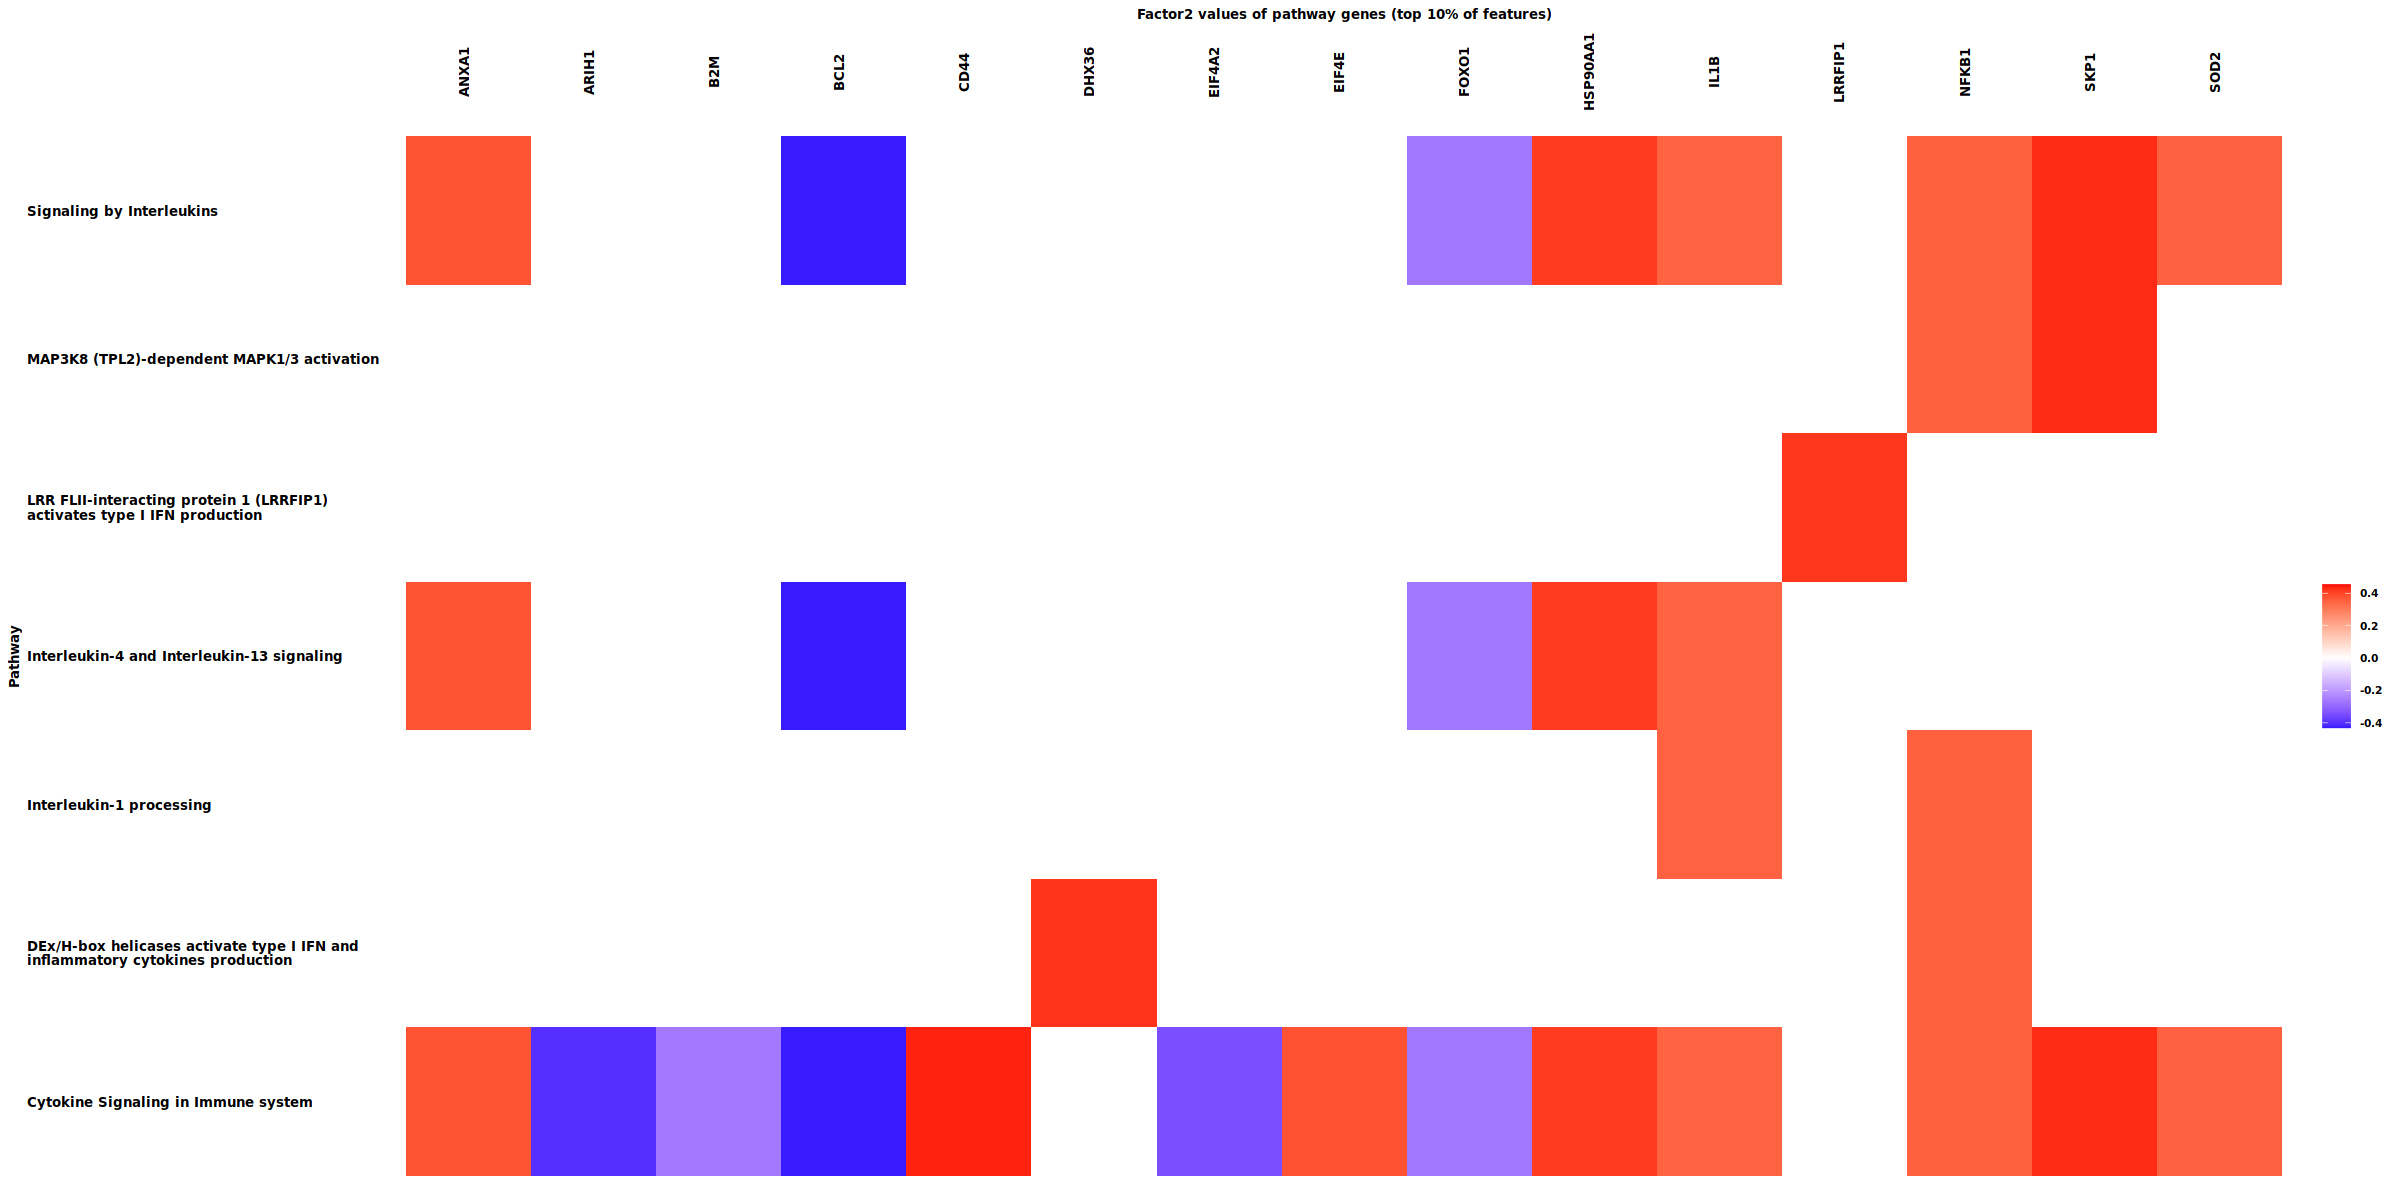

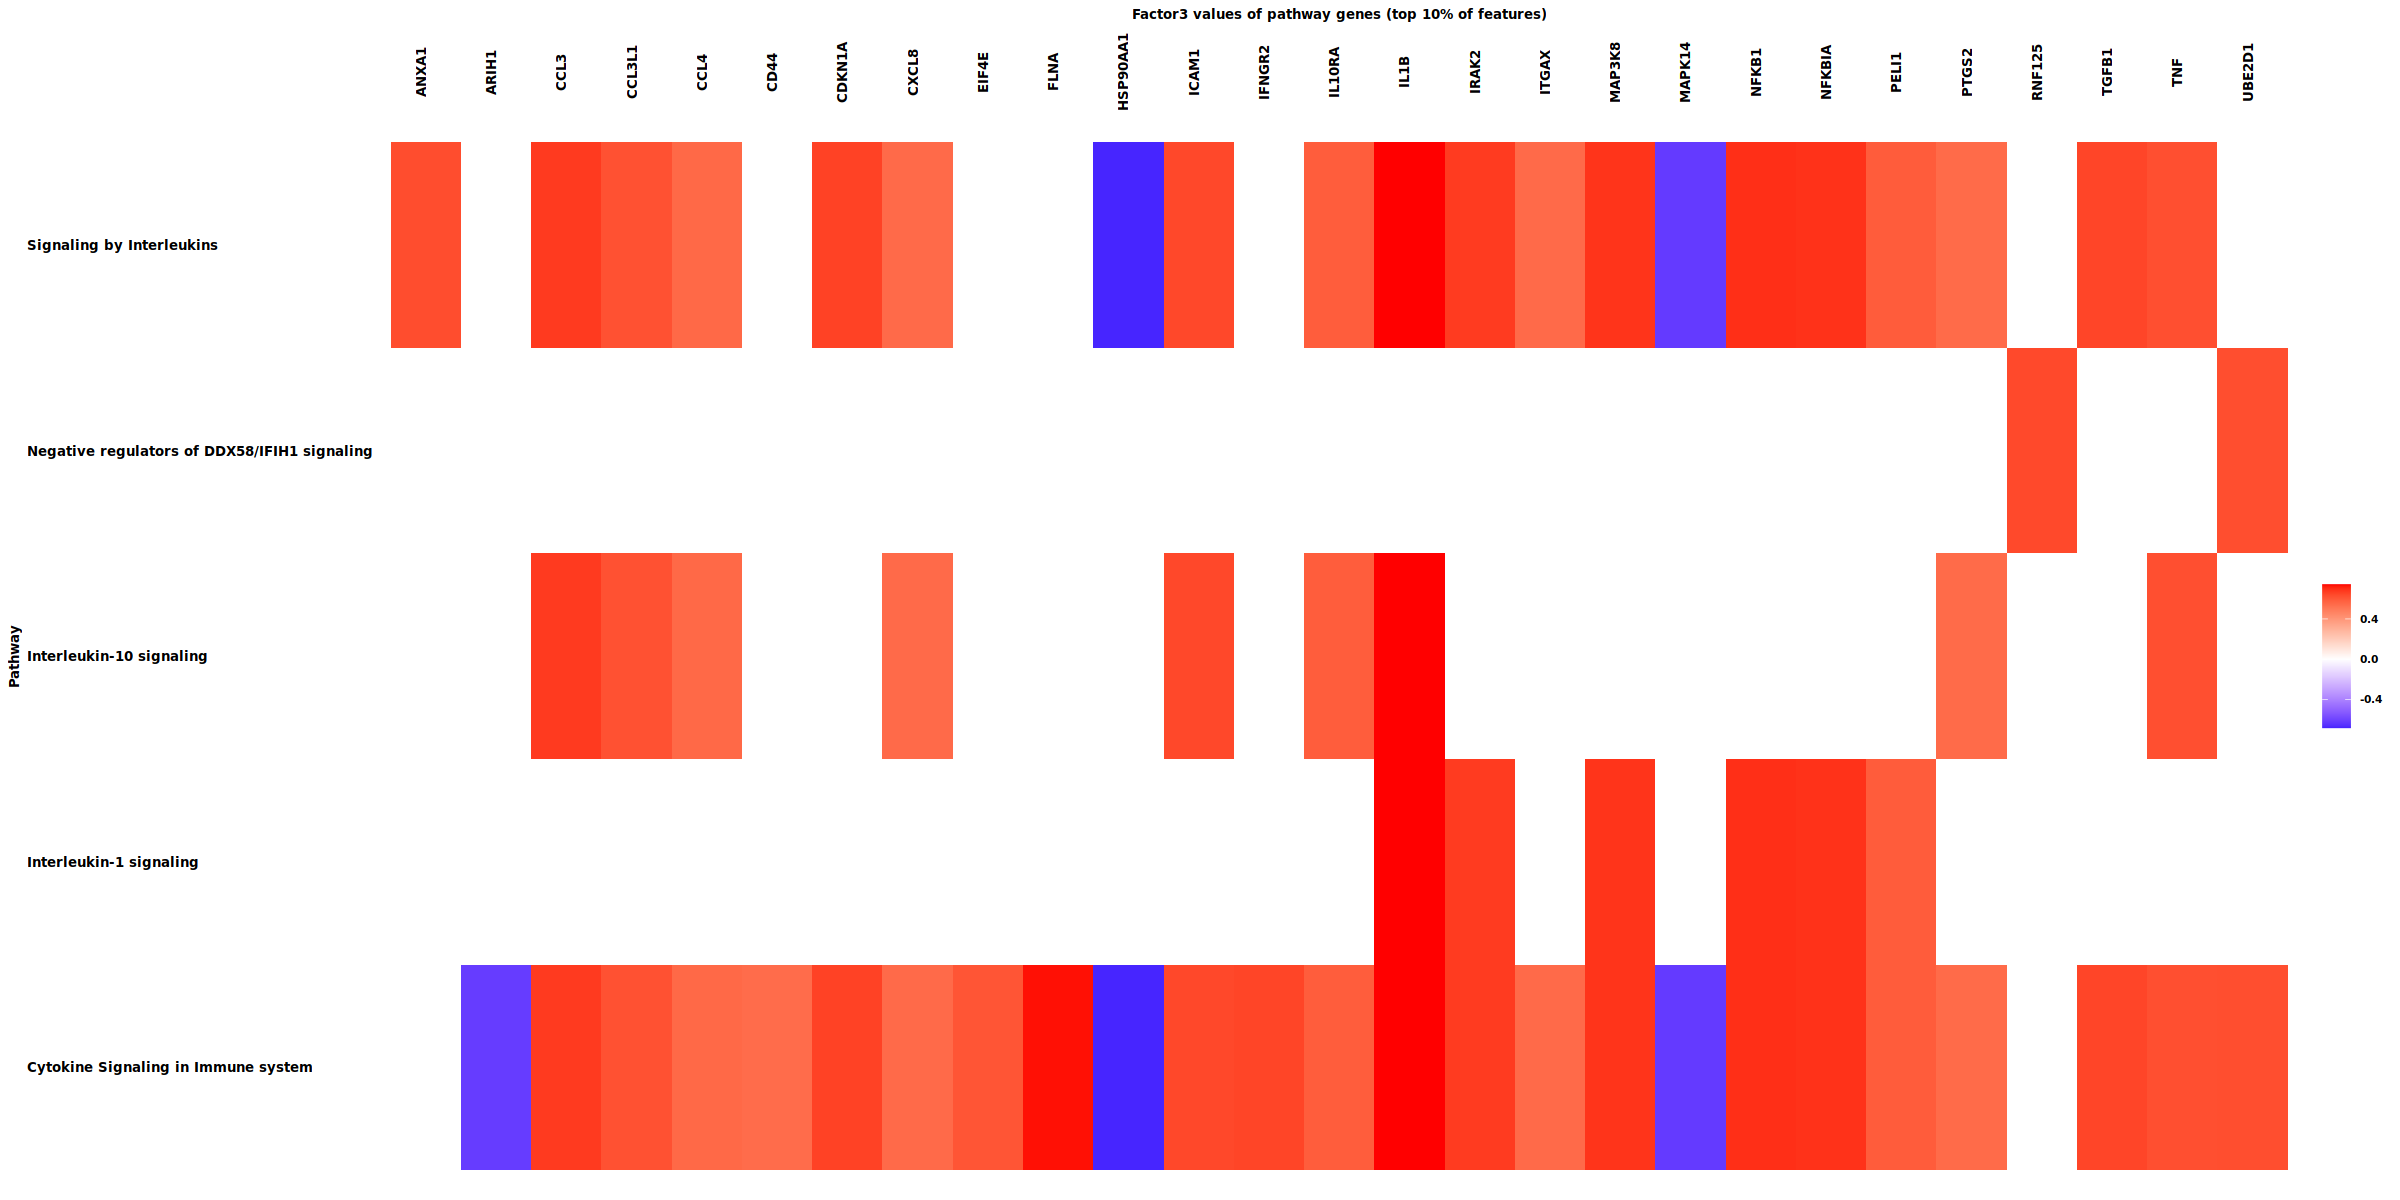

In [151]:
pathways_sum_plot

In [152]:
combined_plot = list()

In [153]:
for(i in 1:length(pathways_detail_plot)){
    combined_plot[[i]] = ggarrange(pathways_sum_plot[[i]],
              pathways_detail_plot[[i]] + theme(axis.text.x = element_blank(), axis.title.x =element_blank()), align = 'v', ncol = 1)
}

In [154]:
#combined_plot[[i]]

In [155]:
## Save the plot

In [156]:
figure_name = paste0( "FIG06_Pathways_and_Genes")

In [157]:
# Sizes of the plot
width_par = 8.07
height_par = 4

In [158]:
pdf(paste0('figures/06_figures/', figure_name, '_',   mofa_name, '.pdf'), width =width_par, height =height_par)

for(j in 1:length(combined_plot)){
        print( combined_plot[[j]])
        }
dev.off()   


png 
  2

In [159]:
### Inform about execution finalization
popup_function_pos('06_Downstream_Pathways: Execution Finished')

In [160]:
Sys.sleep(20)
popup_function_info('06_Downstream_Pathways')